In [7]:
import pandas as pd

df = pd.read_excel("amazon_time_series.xlsx")

df.head()

,Date,Product_Name,Category,Price,Discount_%,Final_Price,Demand_Index,Event
0,Jan,LG 1.5 Ton 5 Star Inverter AC,Appliances,36000,13,31320.0,39,NaN
1,Feb,LG 1.5 Ton 5 Star Inverter AC,Appliances,36000,22,28080.0,28,NaN
2,Mar,LG 1.5 Ton 5 Star Inverter AC,Appliances,40000,17,33200.0,61,NaN
3,Apr,LG 1.5 Ton 5 Star Inverter AC,Appliances,44000,17,36520.0,83,NaN
4,May,LG 1.5 Ton 5 Star Inverter AC,Appliances,44000,11,39160.0,88,NaN


In [8]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

df['Date'] = pd.Categorical(df['Date'], categories=month_order, ordered=True)
df = df.sort_values(by='Date')

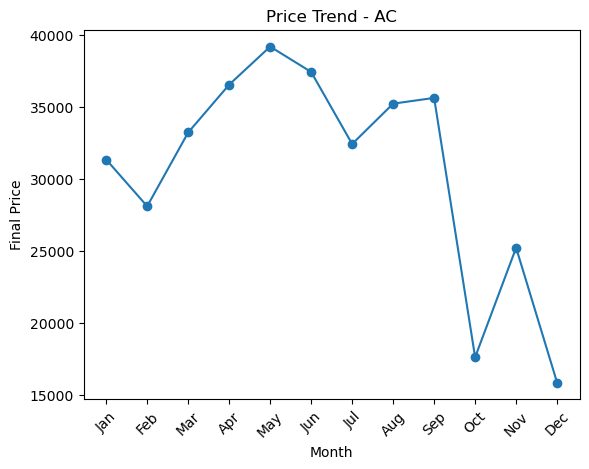

In [9]:
import matplotlib.pyplot as plt

product = "LG 1.5 Ton 5 Star Inverter AC"

data = df[df['Product_Name'] == product]

plt.figure()
plt.plot(data['Date'], data['Final_Price'], marker='o')
plt.title("Price Trend - AC")
plt.xlabel("Month")
plt.ylabel("Final Price")
plt.xticks(rotation=45)
plt.show()

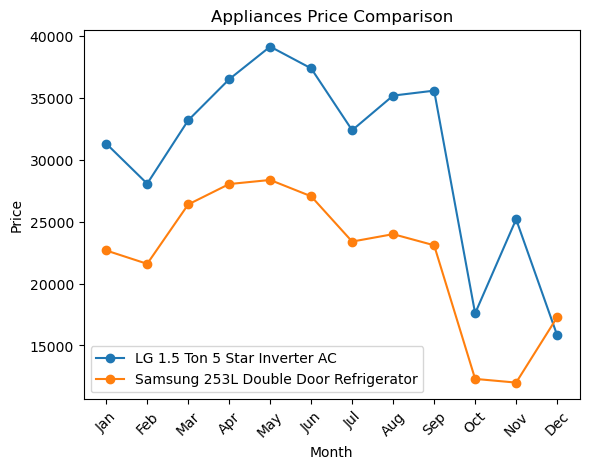

In [10]:
products = ["LG 1.5 Ton 5 Star Inverter AC", "Samsung 253L Double Door Refrigerator"]

for p in products:
    temp = df[df['Product_Name'] == p]
    plt.plot(temp['Date'], temp['Final_Price'], marker='o', label=p)

plt.title("Appliances Price Comparison")
plt.xlabel("Month")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

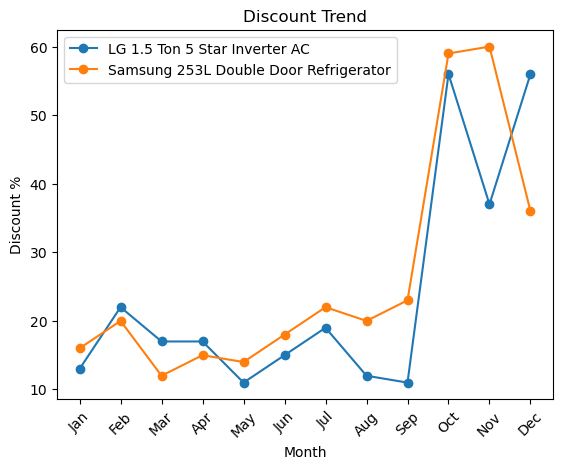

In [11]:
plt.figure()

for p in products:
    temp = df[df['Product_Name'] == p]
    plt.plot(temp['Date'], temp['Discount_%'], marker='o', label=p)

plt.title("Discount Trend")
plt.xlabel("Month")
plt.ylabel("Discount %")
plt.legend()
plt.xticks(rotation=45)
plt.show()

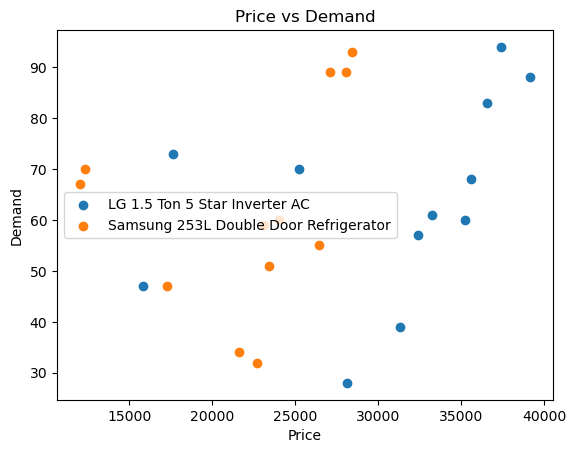

In [12]:
import matplotlib.pyplot as plt

plt.figure()

for p in products:
    temp = df[df['Product_Name'] == p]
    plt.scatter(temp['Final_Price'], temp['Demand_Index'], label=p)

plt.title("Price vs Demand")
plt.xlabel("Price")
plt.ylabel("Demand")
plt.legend()
plt.show()

In [13]:
df[df['Event'] != 'None'].groupby('Product_Name')['Demand_Index'].mean()

Product_Name
Fortune Sunflower Oil 1L                 77.250000
H&M Cotton T-Shirt                       65.750000
Kurkure Masala Munch 100g                77.333333
LG 1.5 Ton 5 Star Inverter AC            64.000000
Mi 20000mAh Power Bank                   69.833333
Nike Revolution Running Shoes            66.250000
Puma Casual Sneakers                     67.750000
Ray-Ban Aviator Sunglasses               71.583333
Samsung 253L Double Door Refrigerator    62.166667
Wildcraft Travel Backpack                71.250000
Zara Winter Puffer Jacket                52.166667
boAt Rockerz 450 Headphones              70.916667
Name: Demand_Index, dtype: float64

In [14]:
df.groupby('Event')['Discount_%'].mean()

Event
Diwali Sale      48.250000
Festive Sale     45.916667
Year-End Sale    48.333333
Name: Discount_%, dtype: float64

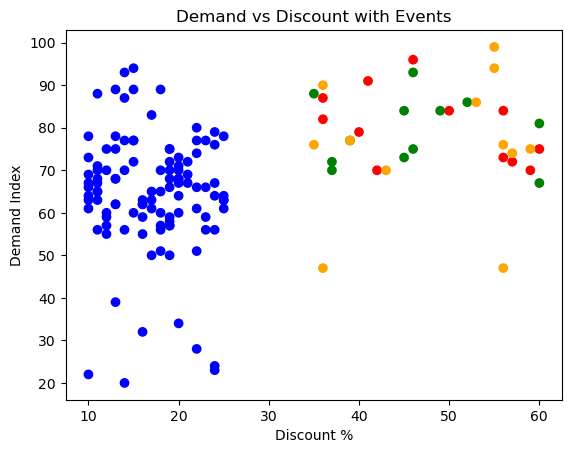

In [16]:
import matplotlib.pyplot as plt

df['Event'] = df['Event'].fillna('None')
df['Event'] = df['Event'].str.strip()

colors = df['Event'].map({
    'None': 'blue',
    'Diwali Sale': 'red',
    'Festive Sale': 'green',
    'Year-End Sale': 'orange'
})

colors = colors.fillna('blue')

plt.figure()
plt.scatter(df['Discount_%'], df['Demand_Index'], c=colors)
plt.xlabel("Discount %")
plt.ylabel("Demand Index")
plt.title("Demand vs Discount with Events")
plt.show()